# 损失与梯度下降：最小补充实验

## 目标（Goal）
解释一次参数更新；比较学习率与特征尺度。与官方 `02-underfitting-overfitting-sklearn.ipynb` 配合使用，约15分钟。

## 来源与范围
损失和库接口依据 [sklearn Linear Models](https://scikit-learn.org/stable/modules/linear_model.html) 与 [SGD](https://scikit-learn.org/stable/modules/sgd.html)，2026-09-05核查。本段 NumPy 梯度循环为课程必要数学补充，不声称直接复制官方代码。`LinearRegression` 的求解器不等同于这里的梯度下降。

## 环境（Setup）
项目基础依赖，CPU、无网络；合成数据不代表现实房价。固定种子42。此处只研究优化行为，使用训练损失；不把它称为泛化评估。

公式：ŷ = Xw；L(w)=平均(ŷ−y)²；∇L=2Xᵀ(Xw−y)/n。第一列常数1吸收截距，w有两个元素。

课堂顺序：一个样本手算→全样本一次更新→重复更新→学习率与尺度。


## 1｜预测为0时，误差有多大？

先只看一个样本：设计行[1,1]、标签3、初始参数[0,0]。你算出的 MSE 是多少？


In [1]:
import numpy as np
import matplotlib.pyplot as plt
single_x = np.array([1., 1.])
single_y = 3.
w = np.zeros(2)
prediction = single_x @ w
error = prediction - single_y
print("预测、残差、损失:", prediction, error, error**2)


预测、残差、损失: 0.0 -3.0 9.0


@ 是向量内积。第一参数是截距，第二参数乘输入。残差为−3，平方损失为9。

<strong>停一下，检查：</strong> 负残差是不是负损失？

<details><summary>查看解释</summary>

不是，残差有方向，平方后损失非负。

</details>


## 2｜参数应该往哪个方向动？

梯度告诉损失增长最快的方向，更新取反方向。先手算 η=0.1 的新参数。


In [2]:
eta = 0.1
gradient = 2 * single_x * error
updated_w = w - eta * gradient
print("梯度:", gradient)
print("新参数与新预测:", updated_w, single_x @ updated_w)


梯度: [-6. -6.]
新参数与新预测: [0.6 0.6] 1.2000000000000002


梯度为[−6,−6]；减去负数使两参数变为0.6，新预测1.2，更接近3。

<strong>停一下，检查：</strong> 如果把损失定义成平方误差/2，梯度如何变？

<details><summary>查看解释</summary>

梯度少一个系数2；若要同样更新量，学习率须加倍。

</details>


一维小结：把上面的双参数例压到一个参数看方向。目标仍是 3，损失 L(w)=(w−3)²；导数 2(w−3) 指向上坡方向，更新沿负方向走。下图三条落点与手算 0 → 0.6 → 1.08 → 1.464 一一对应。

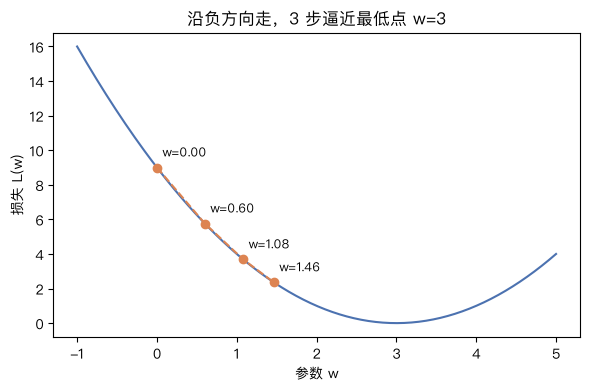

In [3]:
# 一维梯度下降可视化：L(w)=(w-3)^2，与上面手算同一例子
# 图内标签含中文：指定中文字体（macOS 为 PingFang SC，其余按序回退），并禁用 Unicode 负号
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
w = 0.0
path = [w]
for _ in range(3):
    w = w - 0.1 * 2 * (w - 3)   # 导数 2(w-3)，沿负方向走一步
    path.append(w)
grid = np.linspace(-1, 5, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(grid, (grid - 3)**2, color="#4C72B0")
ax.plot(path, [(t - 3)**2 for t in path], "o--", color="#DD8452")
for t in path:                  # 每个落点标参数值，与课件手算数字对得上
    ax.annotate(f"w={t:.2f}", (t, (t - 3)**2),
                textcoords="offset points", xytext=(4, 8), fontsize=9)
ax.set(xlabel="参数 w", ylabel="损失 L(w)", title="沿负方向走，3 步逼近最低点 w=3")
plt.tight_layout(); plt.show()

## 3｜从一个样本扩到80个

把所有样本叠成矩阵；检查行与列，而不是直接背矩阵公式。


In [4]:
rng = np.random.default_rng(42)
x = rng.uniform(-1, 1, 80)
y = 1.5 + 2.5*x + rng.normal(0, 0.15, len(x))
X = np.column_stack([np.ones(len(x)), x])
print("X、y形状:", X.shape, y.shape)
print("前三行:", X[:3])


X、y形状: (80, 2) (80,)
前三行: [[ 1.          0.5479121 ]
 [ 1.         -0.12224312]
 [ 1.          0.71719584]]


X是80×2：每行一个样本，第一列1用于截距。数据和原实验完全相同。

<strong>停一下，检查：</strong> w 应有80项还是2项？

<details><summary>查看解释</summary>

2项，对应2列；X@w输出80个预测。

</details>


## 4｜全样本只更新一次

用平均平方损失 L=mean((Xw−y)²)，观察更新后损失是否下降。


In [5]:
w = np.zeros(X.shape[1])
error = X @ w - y
before = np.mean(error**2)
gradient = 2 * X.T @ error / len(y)
w = w - 0.1 * gradient
print("梯度形状:", gradient.shape)
print("更新前后损失:", before, np.mean((X @ w-y)**2))


梯度形状: (2,)
更新前后损失: 4.187901165629765 3.139471504562214


X.T将80个样本对各参数的贡献汇总；除以80是平均。每次用全样本，称批量梯度下降。

<strong>停一下，检查：</strong> 这一步有没有验证泛化能力？

<details><summary>查看解释</summary>

没有。所有损失都来自训练数据，只研究优化。

</details>


## 5｜将刚才的一步重复100次

下面函数不是新算法：逐行对应刚才的残差、损失、梯度与更新。

### `design` 是什么？

`design` 是函数内部接收**设计矩阵（design matrix）**的参数名。调用 `descend(X, y, 0.1)` 时，前面的 `X` 传给 `design`，`y` 传给 `target`，`0.1` 传给 `eta`；这里没有生成另一份数据，只是在函数内部换了名字。

设计矩阵是统计学和线性回归中的标准术语，按行组织样本、按列组织模型使用的输入项。若有 $n$ 个样本、$p$ 个原始特征，不含截距列时可写为：

$$
X=\begin{bmatrix}
x_{1,1} & x_{1,2} & \cdots & x_{1,p} \\
x_{2,1} & x_{2,2} & \cdots & x_{2,p} \\
\vdots & \vdots & \ddots & \vdots \\
x_{n,1} & x_{n,2} & \cdots & x_{n,p}
\end{bmatrix}\in\mathbb{R}^{n\times p}.
$$

- 每一行是一个样本，每一列是一个特征，形状为 `(n_samples, n_features)`。
- 若把截距也并入矩阵，就在最左边加一列常数 1，形状变为 `(n_samples, n_features + 1)`。设计矩阵还可以包含平方项等变换后的特征列。

**本例只有一个原始特征 $x$，但已经添加了常数列：**

$$
X=\begin{bmatrix}1 & x_1 \\ 1 & x_2 \\ \vdots & \vdots \\ 1 & x_{80}\end{bmatrix},\qquad
w=\begin{bmatrix}b\\w_1\end{bmatrix},\qquad
Xw=\begin{bmatrix}b+w_1x_1\\b+w_1x_2\\\vdots\\b+w_1x_{80}\end{bmatrix}.
$$

所以 `design.shape` 是 `(80, 2)`，`design.shape[1]` 是 2，需要初始化两个参数：截距和斜率。数学式把参数写成列向量；下面 NumPy 代码用形状 `(2,)` 的一维数组保存它，`design @ w` 得到形状 `(80,)` 的预测数组。

**检查：** 如果有 3 个原始特征，并保留这列常数 1，`design` 有几列，`w` 有几个元素？

<details><summary>查看解释</summary>

4 列、4 个参数：一个截距和三个特征的系数。

</details>


In [6]:
def descend(design, target, eta, steps=100):
    w = np.zeros(design.shape[1])
    losses = []
    for _ in range(steps):
        error = design @ w - target
        losses.append(float(np.mean(error**2)))  # 记录更新之前。
        gradient = 2 * design.T @ error / len(target)
        w -= eta * gradient
    return w, np.array(losses)
weights, loss = descend(X, y, 0.1)
print("起始、最后记录损失:", loss[0], loss[-1])


起始、最后记录损失: 4.187901165629765 0.019230458411526107


每次调用从零参数重新开始，保证学习率对照的起点一致。最后记录值在最后更新之前。

<strong>停一下，检查：</strong> loss[-1]等于返回参数weights的损失吗？

<details><summary>查看解释</summary>

不严格相等：记录后还有一次更新。

</details>


## 6｜学习率大一点，一定更快吗？

先预测0.001、0.1、1.2的曲线，再运行。


0.001 最后记录的训练MSE: 3.223556156121154
0.1 最后记录的训练MSE: 0.019230458411526107
1.2 最后记录的训练MSE: 2.173786459434328e+29


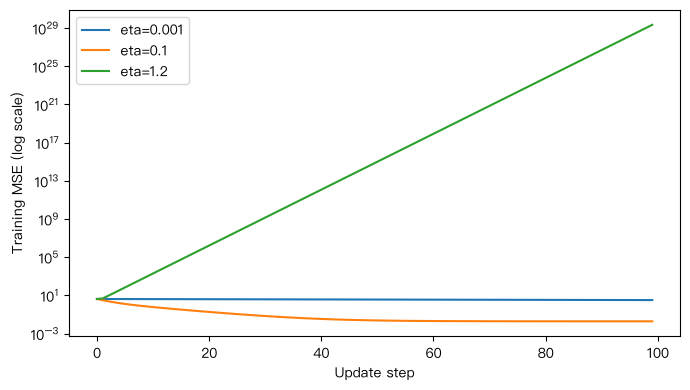

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for eta in [0.001, 0.1, 1.2]:
    w, loss = descend(X, y, eta)
    ax.semilogy(loss, label=f"eta={eta}")
    print(eta, "最后记录的训练MSE:", loss[-1])
ax.set(xlabel="Update step", ylabel="Training MSE (log scale)")
ax.legend(); plt.tight_layout(); plt.show()


纵轴是对数；0.001慢、0.1稳定、1.2失稳是本例结果，不能当通用推荐。

<strong>停一下，检查：</strong> 发散时应先加模型复杂度吗？

<details><summary>查看解释</summary>

先检查步长、尺度、梯度实现；更复杂模型不会自动修正优化错误。

</details>


## 6b｜SGD 与小批量：同一条损失曲线上的噪声

前几格每步用全部 80 个样本（批量 GD）。现在只改一件事——每步看多少样本：批量 80、小批量 32、单样本 1（SGD），学习率同为 0.1，把训练损失（全 80 点 MSE）画在一起。课件「随机梯度下降与小批量」一页说“SGD 步子小、方向抖”，抖成什么样，看曲线。

批量 GD（每步 80 样本） 最后损失: 0.0192
小批量 B=32 最后损失: 0.0192
SGD（每步 1 样本） 最后损失: 0.0202


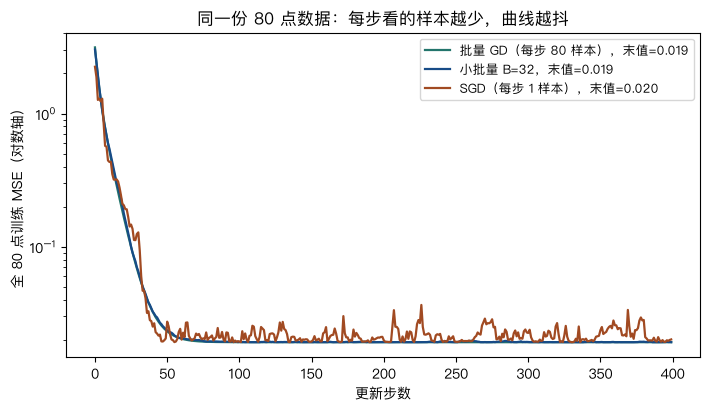

In [8]:
def descend_stochastic(design, target, eta, steps, batch, seed=42):
    rng = np.random.default_rng(seed)
    w = np.zeros(design.shape[1])
    losses = []
    for _ in range(steps):
        idx = rng.choice(len(target), size=batch, replace=(batch == 1))
        error_b = design[idx] @ w - target[idx]
        gradient = 2 * design[idx].T @ error_b / batch   # 与批量同一条平均梯度公式
        w -= eta * gradient
        losses.append(float(np.mean((design @ w - target)**2)))  # 全 80 点训练 MSE
    return losses

plt.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB",
                                    "Microsoft YaHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for label, batch, color in [("批量 GD（每步 80 样本）", 80, "#23756c"),
                            ("小批量 B=32", 32, "#174b87"),
                            ("SGD（每步 1 样本）", 1, "#a14a22")]:
    losses = descend_stochastic(X, y, eta=0.1, steps=400, batch=batch)
    ax.semilogy(losses, lw=1.6, color=color, label=f"{label}，末值={losses[-1]:.3f}")
    print(label, "最后损失:", round(losses[-1], 4))
ax.set_xlabel("更新步数"); ax.set_ylabel("全 80 点训练 MSE（对数轴）")
ax.set_title("同一份 80 点数据：每步看的样本越少，曲线越抖")
ax.legend(fontsize=9)
plt.tight_layout()
# 图像保存在 notebook 输出中，无需向工作目录额外写文件。
plt.show()

## 7｜怎么知道不是自己写错了？

用库的最小二乘解核验充分迭代后的参数。


In [9]:
from sklearn.linear_model import LinearRegression
weights, _ = descend(X, y, 0.1, steps=1000)
reference = LinearRegression().fit(x[:, None], y)
expected = np.array([reference.intercept_, reference.coef_[0]])
print("GD与最小二乘:", weights, expected)
assert np.allclose(weights, expected, atol=1e-6)


GD与最小二乘: [1.48105911 2.53490805] [1.48105911 2.53490805]


库模型自行拟合截距，所以输入原始单列x。两种求解方法目标一致，但LinearRegression不是在调用这里的梯度循环。

<strong>停一下，检查：</strong> 参数吻合能证明真实任务效果好吗？

<details><summary>查看解释</summary>

只能支持实现正确；还需独立评价。

</details>


## 8｜换个单位，原学习率还稳吗？

只把 x 放大100倍，y不变。三条曲线只比较尺度和学习率。


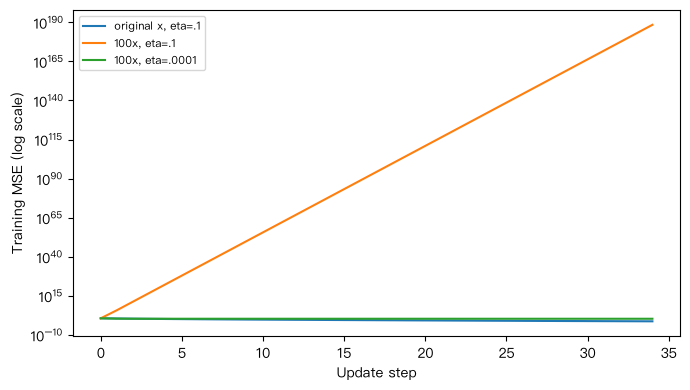

In [10]:
X_large = np.column_stack([np.ones(len(x)), x*100])
settings = [(X, 0.1, "original x, eta=.1"),
            (X_large, 0.1, "100x, eta=.1"),
            (X_large, 0.0001, "100x, eta=.0001")]
fig, ax = plt.subplots(figsize=(7, 4))
for design, eta, label in settings:
    _, loss = descend(design, y, eta, steps=35)
    ax.semilogy(loss, label=label)
ax.set(xlabel="Update step", ylabel="Training MSE (log scale)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()


目标未变，但梯度和曲率尺度改变。标准化常帮助优化，正式任务应仅在训练数据上拟合缩放器。

<strong>停一下，检查：</strong> 将单位放大100倍后，表达同一函数的斜率应怎样变？

<details><summary>查看解释</summary>

缩小100倍，截距不变；但从零开始更新的数值行为会改变。

</details>


## 可选附录｜用有限差分检查梯度

用参数左右微小扰动计算损失斜率，独立检查解析式。

### 这个方法有什么用？

梯度下降依赖我们算出的梯度。求导或代码写错，程序仍可能运行，损失甚至也可能下降。例如漏掉系数 2，相当于把更新步长减半，未必马上报错。**梯度检查（gradient checking）用另一种计算方式，核对导数实现是否与所写的损失函数一致。**

有限差分来自导数的极限定义：不用手工求导，只调用损失函数，观察参数稍微变化后损失改变多少。本节用左右对称的两次计算，即**中心差分（central difference）**。它在这里用于调试与验证，不是另一种参数更新规则。

### 应用场景

| 场景 | 检查什么 |
| --- | --- |
| 本章手写回归梯度 | 系数 2、除以样本数 n、残差符号是否与损失定义一致 |
| 修改损失或加入正则化 | 新增部分是否正确求导并计入梯度 |
| 编写自定义可微运算或反向传播 | 自己实现的导数是否与前向计算一致；PyTorch 的 gradcheck 可用于这类校验 |

实际使用时，先固定小批数据，在几个不同参数位置检查，再开始长时间训练。左右两次计算应使用同一批样本和相同随机状态，避免把数据或随机性的变化误当作参数扰动的效果。

### 为什么不在训练的每一步都这样算？

按本节逐参数中心差分的写法，P 个参数需要约 2P 次损失计算才能得到一遍梯度。参数很多时开销大，因此常用于小规模校验；正式训练通常使用解析梯度或自动微分。

检查通过只支持“这些测试点上，梯度与实现的损失一致”，不证明损失函数本身选得合理，也不证明模型泛化良好。检查失败也未必是公式错：步长、浮点精度、随机性和不可导点都会影响结果。通常使用双精度，避开不可导点，例如绝对值函数在 0 处。

**官方资料（2026-09-27 核查）：** [SciPy check_grad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.check_grad.html) 使用前向差分核对梯度，与本节中心差分写法略有不同；[PyTorch gradcheck 原理](https://docs.pytorch.org/docs/stable/notes/gradcheck.html)介绍数值梯度与自动微分结果的对照；[精度与不可导点注意事项](https://docs.pytorch.org/docs/main/generated/torch.autograd.gradcheck.gradcheck.html)。本节无需安装 PyTorch。


In [11]:
w0 = np.array([0.3, -0.2])
eps = 1e-6
grad = 2 * X.T @ (X @ w0 - y) / len(y)
finite = []
for direction in np.eye(2):
    right = np.mean((X @ (w0 + eps*direction) - y)**2)
    left = np.mean((X @ (w0 - eps*direction) - y)**2)
    finite.append((right-left)/(2*eps))
print("解析与差分:", grad, finite)
assert np.allclose(grad, finite, atol=1e-6)


解析与差分: [-2.4337548  -1.62853613] [np.float64(-2.4337548034658596), np.float64(-1.6285361337242676)]


这里逐个扰动参数，避免用一行嵌套推导掩盖验证过程。

<strong>停一下，检查：</strong> 为什么不让eps很大？

<details><summary>查看解释</summary>

一般非二次损失中，步长过大会增大局部近似误差；过小又会因两个相近损失相减而放大浮点舍入影响。本例是二次损失，中心差分在精确算术下对任意非零步长都等于中心导数，但实际计算仍受浮点误差影响。

</details>


### 图解：只改变一个参数，观察损失变化

固定 `w[0]`，只对 `w[1]` 做左右扰动。蓝线为当前数据的损失，橙线连接左右两点，绿虚线是中心点的切线。上面的代码仍检查两个参数分量，图只展示其中一个，计算方法相同。

$$\frac{\partial L}{\partial w_j}\approx\frac{L(w_0+\varepsilon e_j)-L(w_0-\varepsilon e_j)}{2\varepsilon}$$

为了看清左右两点，**图中间隔使用 h=0.35；上面的数值校验仍用 ε=10⁻⁶**。图内报告的是上面实际计算的解析梯度和数值差分。这里线性回归的 MSE 沿单个参数是二次函数：在精确算术下，中心差分恰好等于中心导数，因此橙色割线与绿色切线平行；一般非二次损失只是近似。


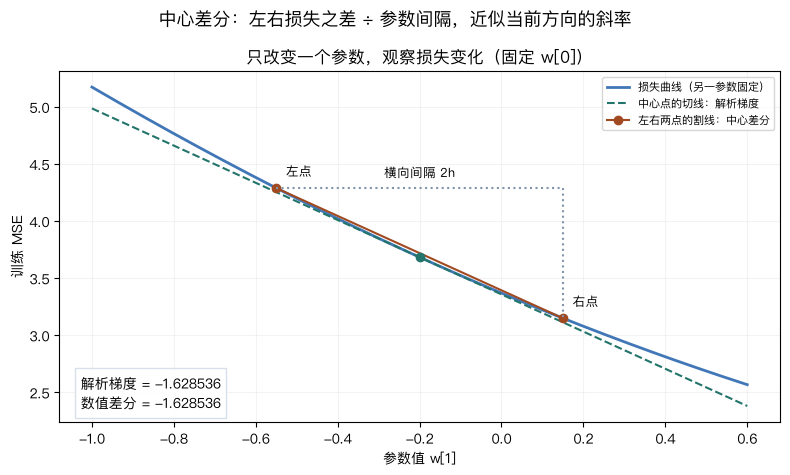

In [12]:
# 绘图辅助只画损失与斜率；梯度计算保留在上一格。
from helpers.gradient_check_plot import plot_gradient_check
plot_gradient_check(X, y, w0, grad, finite)
